In [7]:
from Tools_LGTs_SCQs_Dec25 import *

### This notebook reproduces the plots obtained in "MISSION-Mathieu_basis_sparse_2D_different_m_other_my_take.ipynb" ($N=13$, several $\lambda/g$ and $\lambda/m$)

In [8]:
N = 13
N_θ = 10001

filename = f"plaquette_reduced4vars_alphas0_mathieubasis_expvals_Pop_nsqr_data_several_λ_ovr_m_λ_ovr_g_0_1_to_1000_N_{N}_Ntheta_{N_θ}_mytake.npz"

data = np.load(filename)

λ_ovr_g = data['lambda_over_g']
λ_ovr_m = data['lambda_over_m']
expval_Pop_0 = data['expvals_plaquette_operator']
expval_n_sqr_0 = data['expvals_n12_sqr']
N = data['N']
N_θ = data['N_θ']

In [9]:
# Zheng data for infinity behaviour comparison

λ_ovr_g_infty = np.exp(np.linspace(np.log(0.1), np.log(1000), 41))
results_nsqr_infty = np.array([4.93536591e-03, 7.76353191e-03, 1.21607024e-02, 1.89249656e-02,
     2.91648380e-02, 4.43046510e-02, 6.59547345e-02, 9.55638263e-02,
     1.33880392e-01, 1.80489838e-01, 2.33847813e-01, 2.91961607e-01,
     3.53321457e-01, 4.17491824e-01, 4.85133814e-01, 5.57650253e-01,
     6.36759864e-01, 7.24198840e-01, 8.21603850e-01, 9.30534585e-01,
     1.05255997e+00, 1.18934724e+00, 1.34272825e+00, 1.51474448e+00,
     1.70768155e+00, 1.92410161e+00, 2.16687789e+00, 2.43923298e+00,
     2.74478169e+00, 3.08757911e+00, 3.47217445e+00, 3.90367142e+00,
     4.38779603e+00, 4.93097254e+00, 5.54040875e+00, 6.22419164e+00,
     6.99139472e+00, 7.85219837e+00, 8.81802502e+00, 9.90169065e+00,
     1.11175749e+01])
results_Pop_infty = np.array([9.65920398e-05, 2.37827679e-04, 5.79023269e-04, 1.38564652e-03,
     3.23138565e-03, 7.25717060e-03, 1.54622679e-02, 3.07323504e-02,
     5.61040938e-02, 9.31544671e-02, 1.40592484e-01, 1.94599802e-01,
     2.50807307e-01, 3.06089828e-01, 3.58997352e-01, 4.09199898e-01,
     4.56792248e-01, 5.01886667e-01, 5.44497385e-01, 5.84572721e-01,
     6.22055858e-01, 6.56922996e-01, 6.89194647e-01, 7.18931783e-01,
     7.46226984e-01, 7.71195409e-01, 7.93967072e-01, 8.14680603e-01,
     8.33478352e-01, 8.50502639e-01, 8.65892953e-01, 8.79783923e-01,
     8.92303919e-01, 9.03574146e-01, 9.13708120e-01, 9.22811449e-01,
     9.30981826e-01, 9.38309193e-01, 9.44876017e-01, 9.50757647e-01,
     9.56022722e-01])

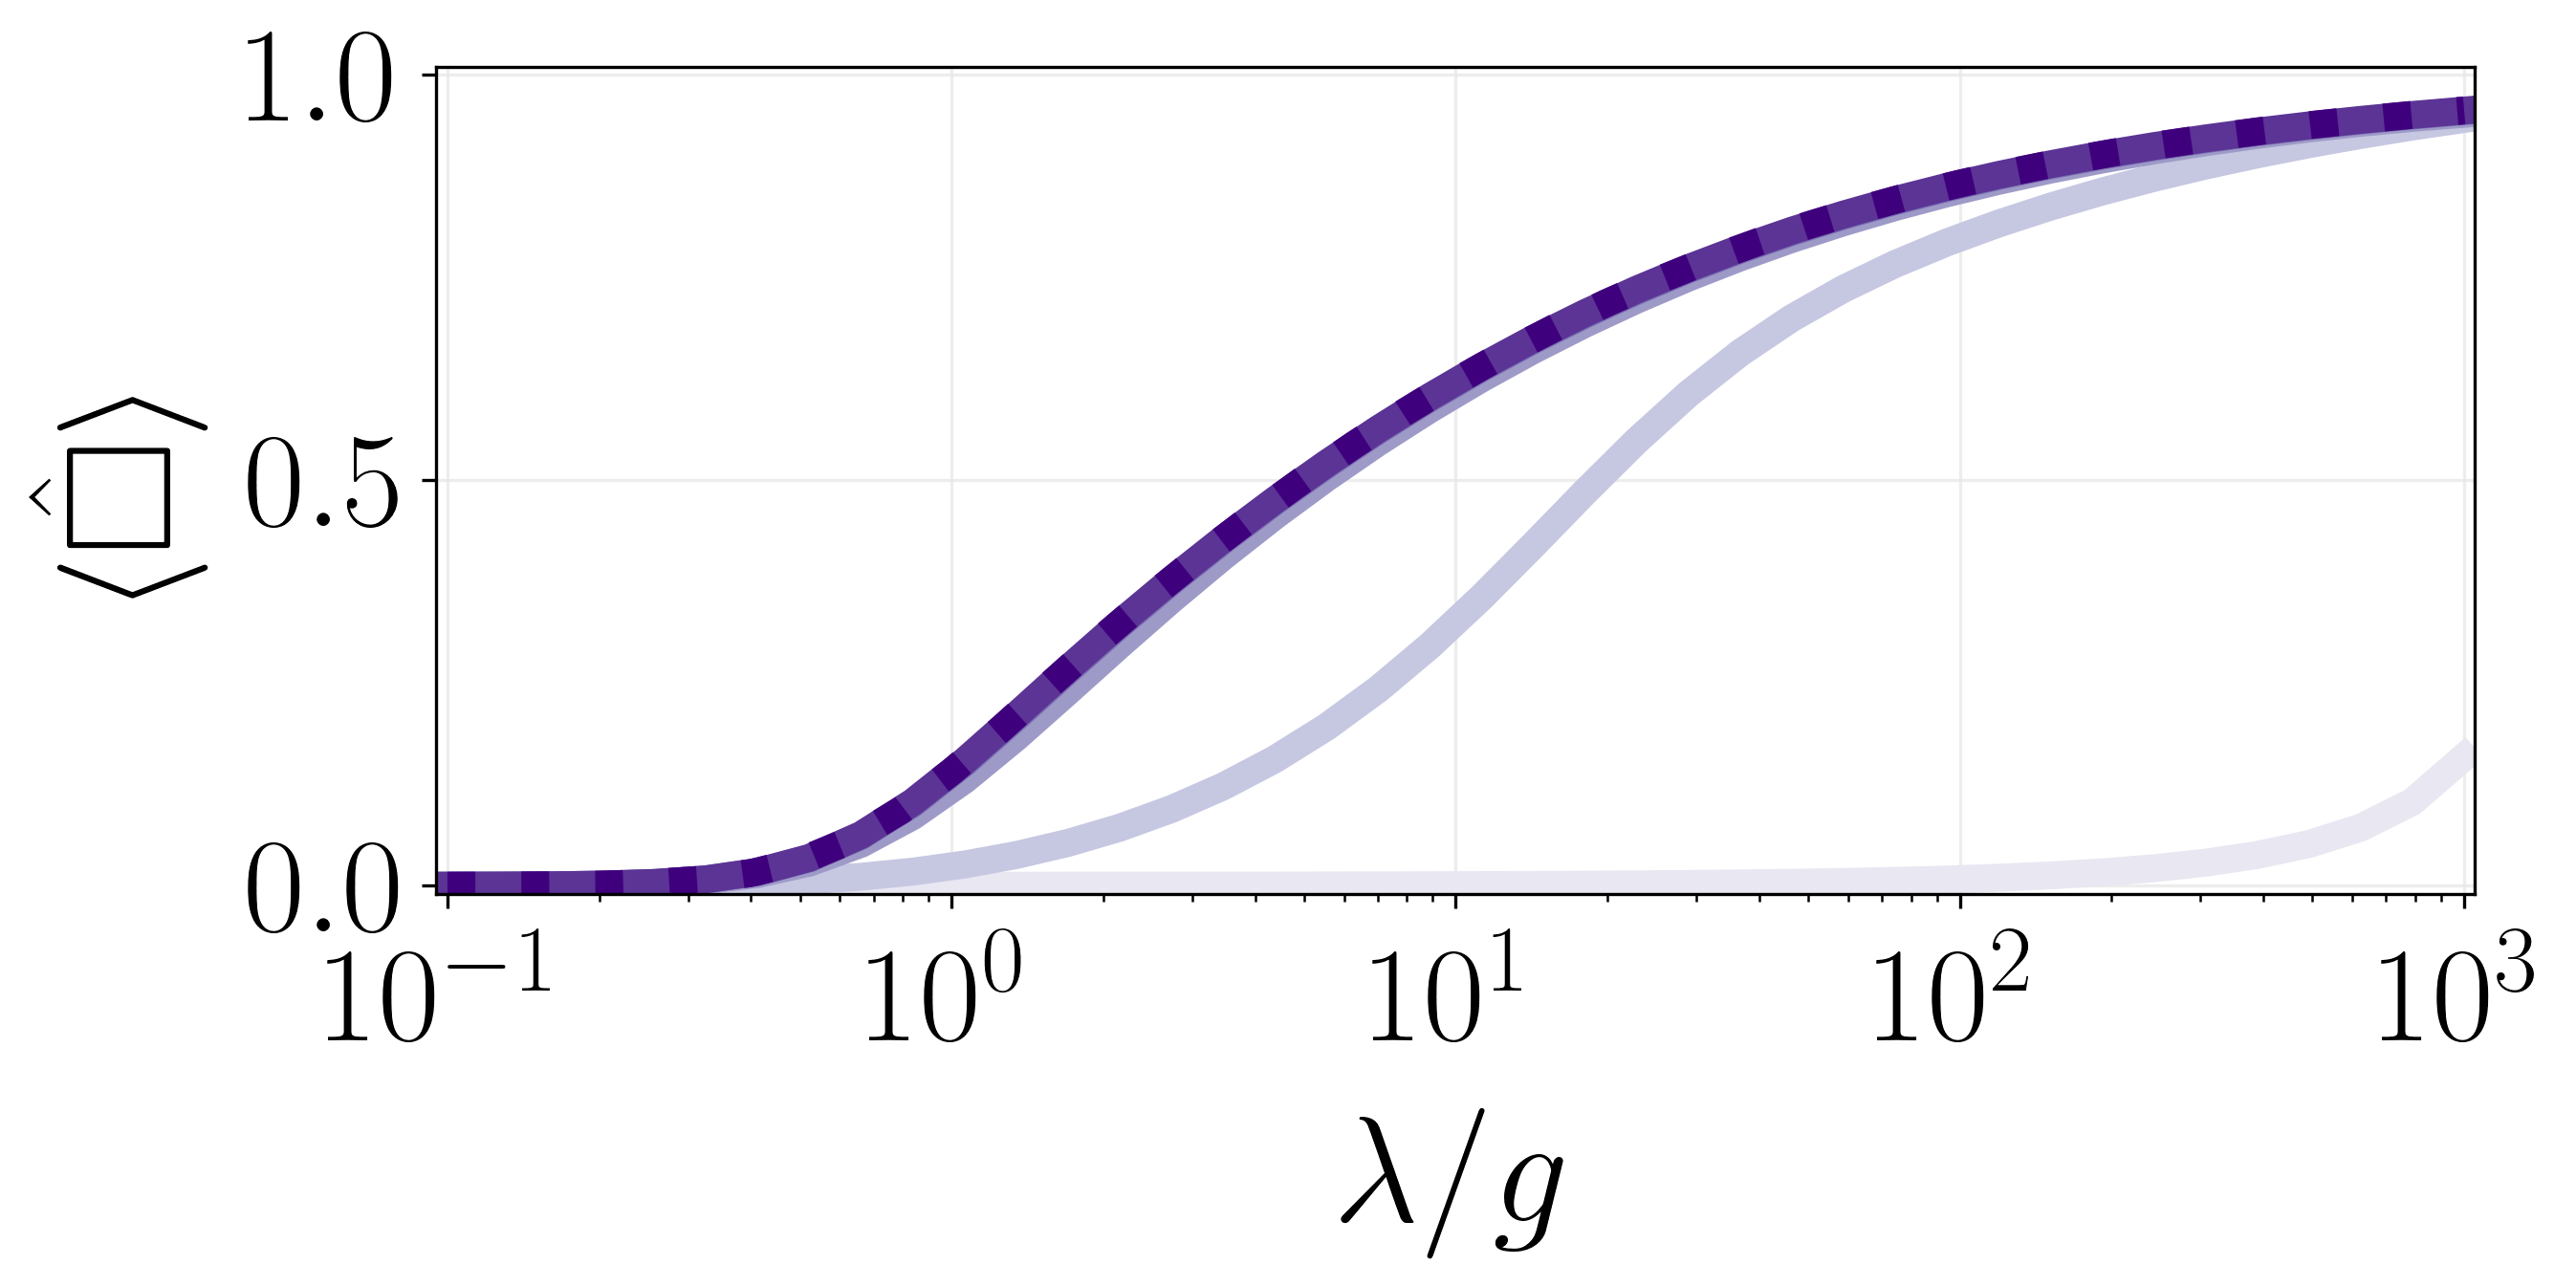

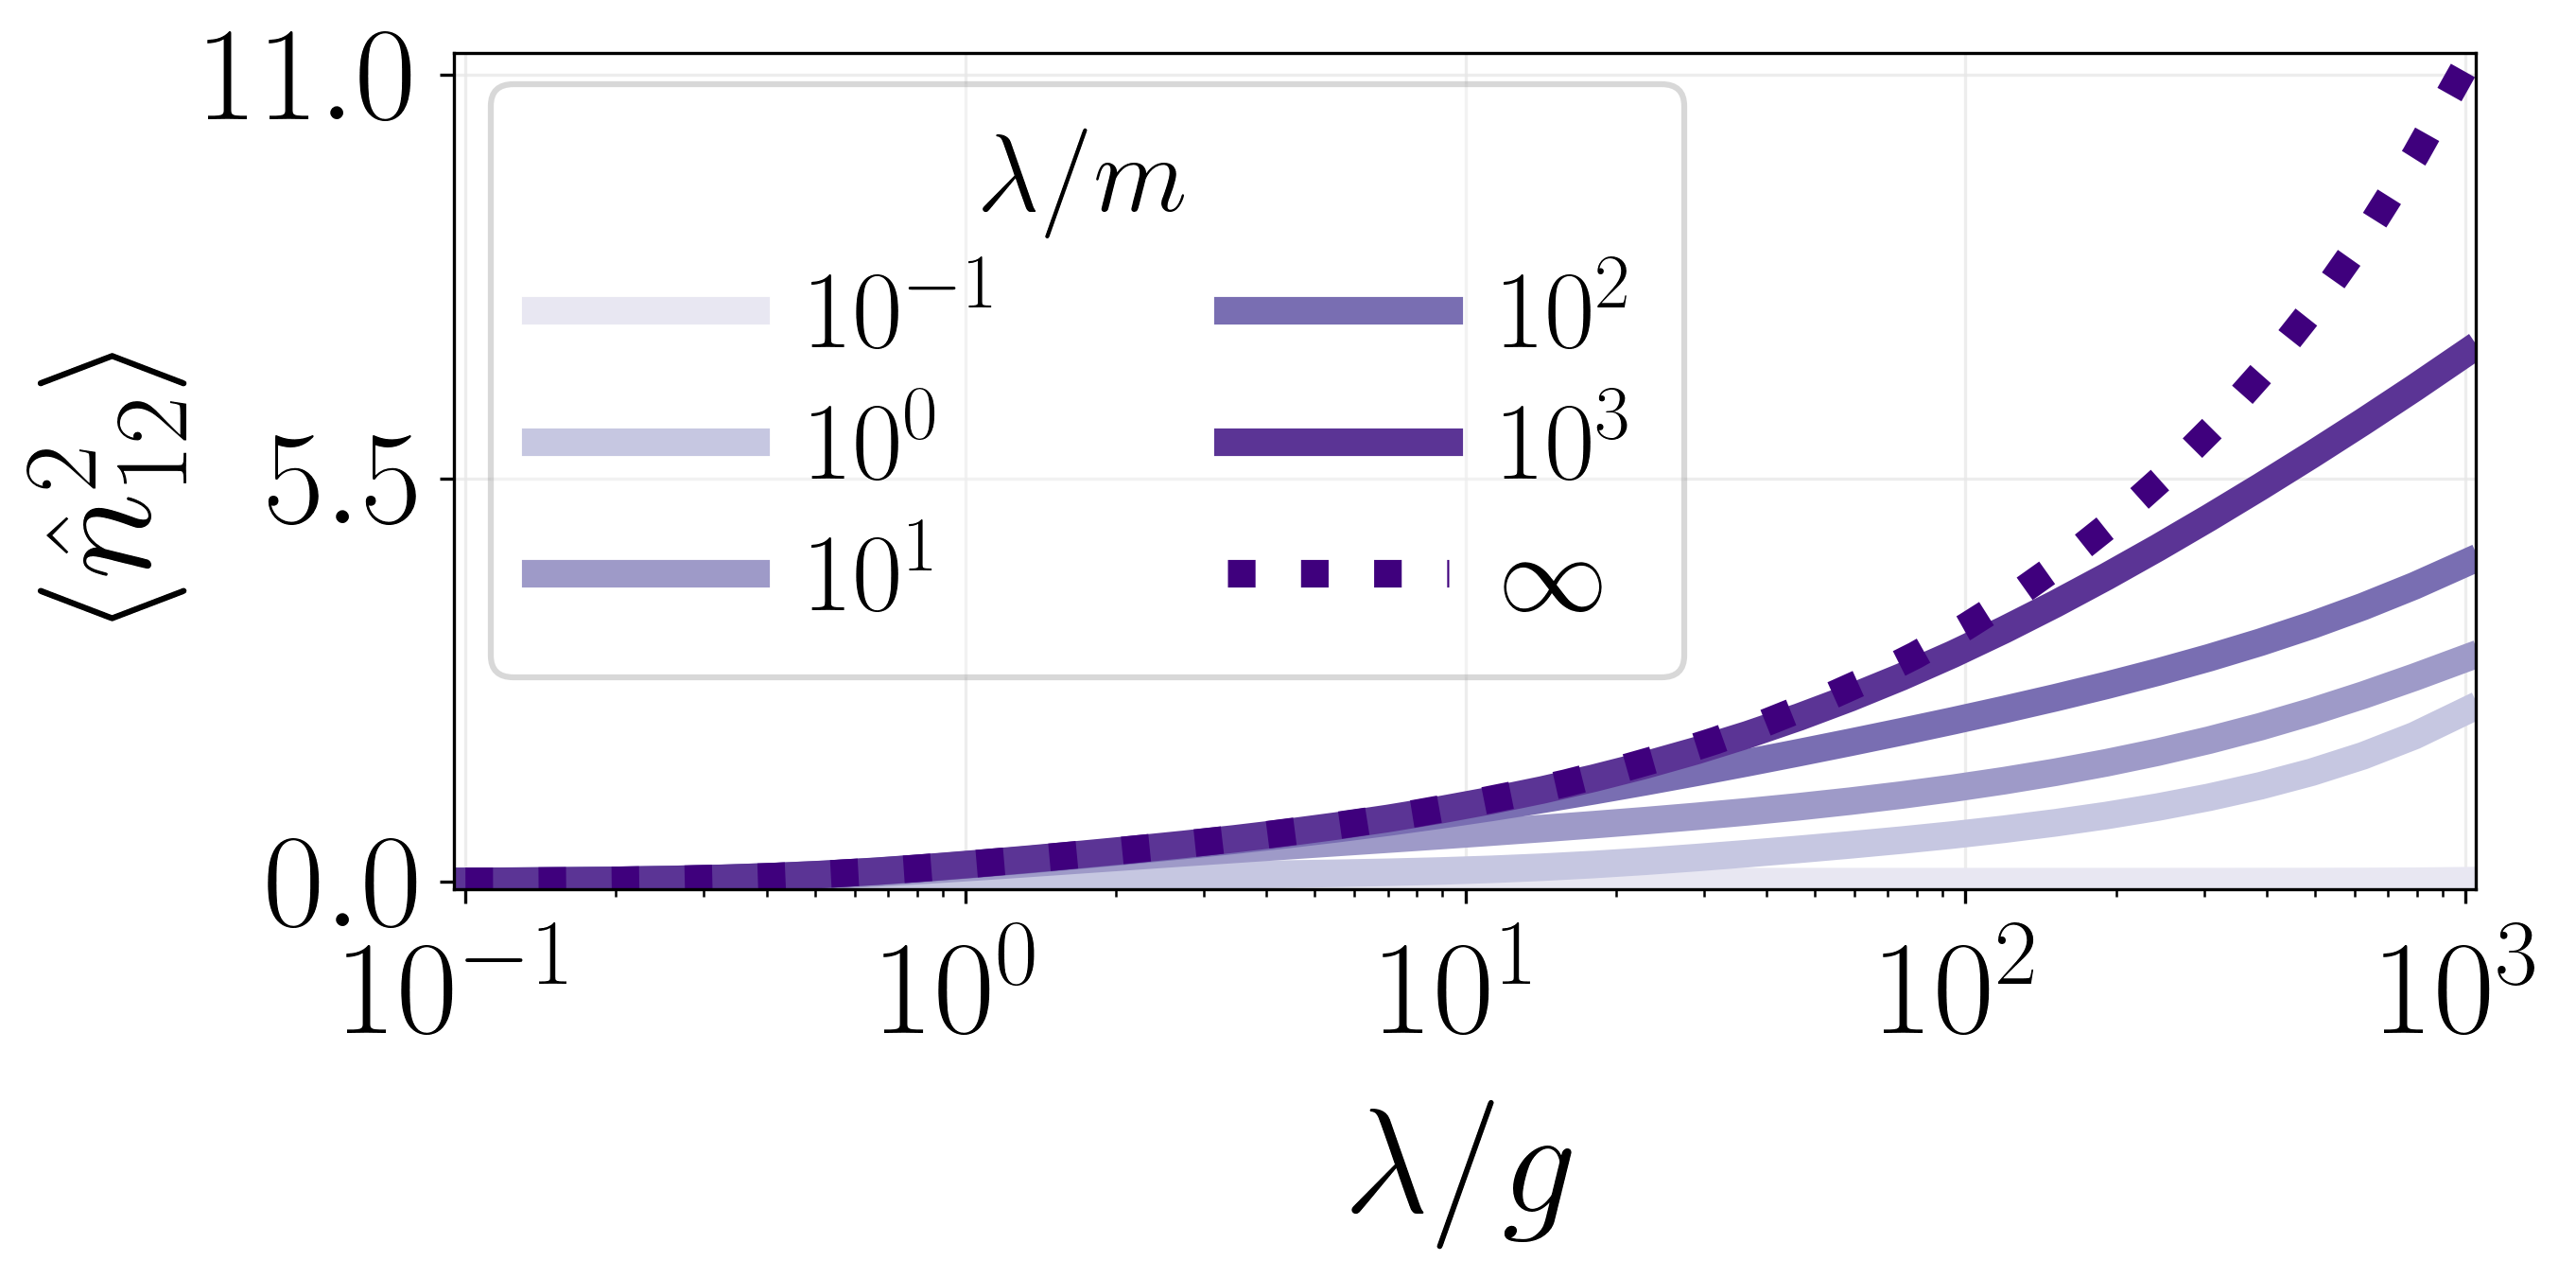

In [10]:
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

plt.rcParams.update({
    #"figure.figsize": (8, 5),
    "figure.dpi": 100,
    "font.size": 24,
    "font.family": "serif",
    "text.usetex": True,
    "axes.labelsize": 38,
    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "axes.titlesize": 14,
    "axes.grid": False,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "legend.fontsize": 14,
    "legend.title_fontsize": 16,
    "legend.frameon": False,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
})

fig1, ax1 = plt.subplots(figsize=(9.5, 5), dpi = 300)

colors = plt.cm.Purples(np.linspace(0, 1, len(λ_ovr_m)+2))

def sci_label(x):
    mantissa, exponent = f"{x:.0e}".split("e")
    return rf"$10^{{{int(exponent)}}}$"

for i, λ_m in enumerate(λ_ovr_m):
    ax1.semilogx(
        λ_ovr_g,
        expval_Pop_0[i],
        label= sci_label(λ_m),
        color=colors[i+1],
        linewidth=7
    )


ax1.semilogx(
    λ_ovr_g_infty, results_Pop_infty,
    color=colors[-1], linestyle=':', label=r'$\infty$', linewidth=7
)

ax1.set_xlabel(r"$\lambda/g$", labelpad=10)
#ax1.set_ylabel(r"$\langle \hat{\Box} \rangle_{\rm gs}^{\mathcal{M}, \rm num}$", labelpad=10)
ax1.set_ylabel(r"$\langle \hat{\Box} \rangle$", labelpad=10)
ax1.set_xlim(0.095, 1050)
ax1.set_ylim(-0.01, 1.01)
ax1.grid(color="0.9")
ax1.tick_params(axis='x', pad=10)  # 10 points of padding
ax1.set_yticks([0.0, 0.5, 1.0])

#ax1.legend(
#    title = r"$\lambda/m$",
#    title_fontsize=28,
#    fontsize=28, ncol=2,
#    loc="lower right",
#    bbox_to_anchor=(0.52, 0.50),
#    borderpad=0.4,
#    labelspacing=0.3,
#    handletextpad=0.5,
#    borderaxespad=0.4
#)

plt.tight_layout()
fig1.savefig(
    f"LGT_SCQs_plaquette_reduced_def_OCT25/"
    f"LGT_SCQs_plaquette_reduced4vars_alphas0_mathieubasis_expvals_Pop_data_several_λ_ovr_m_λ_ovr_g_0_1_to_1000_N_{N}_Ntheta_{N_θ}_mytake_2.pdf",
    dpi = 600
)
plt.show()

fig2, ax2 = plt.subplots(figsize=(9.6, 5), dpi = 300)

for i, λ_m in enumerate(λ_ovr_m):
    ax2.semilogx(
        λ_ovr_g,
        expval_n_sqr_0[i],
        label= sci_label(λ_m),
        color=colors[i+1],
        linewidth=7
    )

ax2.semilogx(
    λ_ovr_g_infty, results_nsqr_infty,
    color=colors[-1], linestyle=':', label=r'$\infty$', linewidth=7
)

ax2.set_xlabel(r"$\lambda/g$", labelpad=10)
#ax2.set_ylabel(r"$\langle \hat{n}^2_{\theta} \rangle_{\rm gs}^{\mathcal{M}, \rm num}$", labelpad=10)
ax2.set_ylabel(r"$\langle \hat{n}^2_{12} \rangle$", labelpad=5)
ax2.set_xlim(0.095, 1050)
ax2.set_ylim(-0.1, 11.3)
#ax2.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax2.grid(color="0.9")
ax2.tick_params(axis='x', pad=10)  # 10 points of padding
ax2.set_yticks([0, 5.5, 11])

leg_2 = ax2.legend(
    title = r"$\lambda/m$",
    title_fontsize=28,
    fontsize=28, ncol=2,
    loc="lower right",
    bbox_to_anchor=(0.63, 0.20),
    borderpad=0.4,
    labelspacing=0.3,
    handletextpad=0.5,
    borderaxespad=0.4,
    frameon=True,
    fancybox=True      # rounded corners
)
frame = leg_2.get_frame()
frame.set_linewidth(1.5)
frame.set_edgecolor("grey")
frame.set_alpha(0.3)
leg_2.get_title().set_fontweight("bold")

plt.tight_layout()
fig2.savefig(
    f"LGT_SCQs_plaquette_reduced_def_OCT25/"
    f"LGT_SCQs_plaquette_reduced4vars_alphas0_mathieubasis_expvals_nsqr_data_several_λ_ovr_m_λ_ovr_g_0_1_to_1000_N_{N}_Ntheta_{N_θ}_mytake_2.pdf",
    dpi = 600
)
plt.show()